# Tutorial 04: Basic Fitting Workflow

## Overview

This tutorial fits a disc model to real data, start to finish, using two files that ship
with the package — Swift XRT and Swift/UVOT observations of AT2019dsg. Nothing here depends
on an external database, so it runs on a fresh install.

It also answers a question you should be asking of any fitting package: **how much can I
trust the number it gives me?** We fit the same model, from the same starting point, twice
— once with X-rays alone and once with a single UV band added — and the black hole mass
moves by a factor of ten. That is not a defect in the optimiser. It is the most important
thing in this notebook.

## Learning Objectives

By the end of this tutorial, you will:

- Understand the `Fit` class and what it adds to a model
- Know how priors are set up, and how to change them
- Be able to run a maximum-likelihood fit with `best_fit()`
- Know how to inspect the result and overlay it on the data
- Understand that *which data you include* matters more than which optimiser you use
- Understand why a single best-fit point is rarely the answer you want

## Prerequisites

- **Tutorial 01: Data Loading Basics**
- **Tutorial 03: Model Setup and Parameters** — in particular `pack_parameters()`

## The Fit class

A `GR_disc` knows how to compute a light curve and, given data, how to compute a
likelihood. A `Fit` wraps a model together with a prior and provides the statistical
machinery: optimisation, MCMC, nested sampling, and the plotting that goes with them.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


## Step 1: load the data

Two files ship in `fitted/examples/`, both real observations of AT2019dsg:

- `2019dsg_Xray.txt` — Swift XRT, ten detections and fourteen upper limits, as observed
  fluxes.
- `2019dsg_UVW1.txt` — Swift/UVOT UVW1, host-subtracted rest-frame νL_ν, via the manyTDE
  catalogue.

Upper limits matter. Fourteen of the twenty-four X-ray epochs are non-detections, and a
model that overpredicts the early X-ray flux has to be rejected by *something*. That
something is the upper limits, which enter the likelihood as one-sided constraints.

In [2]:
from astropy import units

examples = package_dir / 'fitted' / 'examples'
D_Mpc = 236.4                                    # AT2019dsg luminosity distance

# ---- X-ray: the file holds observed fluxes, so convert to luminosity ----
raw = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3)
kind = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3,
                     usecols=(1), dtype=str)
scale = 4 * np.pi * (D_Mpc * units.Mpc.to(units.cm))**2
detected, limit = kind == 'X', kind == 'XUL'

args_X = [[raw[:, 0][detected], raw[:, 2][detected] * scale,
           raw[:, 3][detected] * scale, [0.3, 10]]]
args_X_ul = [[raw[:, 0][limit], raw[:, 2][limit] * scale,
              3 * np.ones(limit.sum()), [0.3, 10]]]     # 3-sigma limits

# ---- UVW1: already rest-frame nu L_nu, so no conversion ----
uv = np.genfromtxt(examples / '2019dsg_UVW1.txt')
t_uv, L_uv, e_uv = uv[:, 0], uv[:, 1], uv[:, 2]
NU_UVW1 = 1.198891e15                            # Hz, rest frame (see the file header)

print("X-ray:  %2d detections, %2d upper limits, %5.0f to %5.0f days"
      % (detected.sum(), limit.sum(), raw[:, 0].min(), raw[:, 0].max()))
print("UVW1:   %2d points,%18s %5.0f to %5.0f days"
      % (len(t_uv), '', t_uv.min(), t_uv.max()))

X-ray:  10 detections, 14 upper limits,    16 to   154 days
UVW1:   36 points,                      16 to  1882 days


### Which UV points to use, and why not all of them

We will not use all of the UVW1 data, and the reason is physical rather than convenient.

The early optical and UV emission of a TDE is **not** disc emission. It is the flare
component that FitTeD models separately with `decay` / `rise` (Tutorial 03), and it
dominates for the first few months. A disc-only model asked to fit the early UV will
distort the disc parameters trying to reproduce light the disc cannot produce.

By late times that component has faded and the UV is disc-dominated. So we keep UVW1 beyond
150 days — roughly ten viscous times for this object — and fit the disc alone.

This is a real modelling choice, and it is worth being honest that the result depends on it:
the cut has to be late enough that the flare has gone, and early enough to leave data. The
alternative is Tutorial 06, which turns the early-time component on and fits everything
together, at the cost of six more parameters.

In [3]:
T_UV_MIN = 150.0                                 # days; disc-dominated beyond this
late = t_uv > T_UV_MIN

print("keeping %d of %d UVW1 points (t > %.0f d)"
      % (late.sum(), len(t_uv), T_UV_MIN))

common = dict(args_X=args_X, bands_X=['Swift XRT'],
              args_X_upperlim=args_X_ul, bands_X_upperlim=['Swift XRT upper limit'])

# Two data sets. We fit both, because the comparison is the point of this tutorial.
data_xray = fitted.data.Data_Set(**common)
data_both = fitted.data.Data_Set(
    args_UV=[[t_uv[late], L_uv[late], e_uv[late], NU_UVW1]],
    bands_UV=['UVW1'],
    global_systematic=0.1,      # 10% of the luminosity, added in quadrature
    **common)

print("\nX-ray only:    %d points" % detected.sum())
print("X-ray + UVW1:  %d points" % (detected.sum() + late.sum()))

keeping 15 of 36 UVW1 points (t > 150 d)
No default colour for band UVW1, colour for this band currently default matplotlib colour 0.

X-ray only:    10 points
X-ray + UVW1:  25 points


`global_systematic=0.1` adds 10% of the luminosity in quadrature to every uncertainty. For
a TDE this is not a fudge factor — it is a statement that a smooth disc model is not
expected to reproduce the data to the photometric precision of Swift, because the model is
smooth and the source is not.

## Step 2: build the model

Disc only — `decay=False`. At 0.3–10 keV the early-time component (a ~10⁴·⁵ K blackbody)
emits nothing measurable, and beyond 150 days it has faded from the UV too. Including it
here would add four unconstrained parameters; try it and you will find `log_L` wandering off
to absurd values because nothing in the data can push back on it.

Fit the components your data can actually see.

In [4]:
def disc_model(data):
    # Disc-only GR_disc on a given data set; all other options at their defaults.
    return fitted.models.GR_disc(data=data, decay=False)

model = disc_model(data_both)
model.what_pars()


You are using the GR_disc model class.
This model samples 7 key parameters and 0 early-time parameters,
in this order:

  [ 0] log_mh      = the logarithm of the black hole mass in units of solar masses.
  [ 1] a_bh        = the black hole spin (dimensionless -0.999 < a_bh < 0.999).
  [ 2] log_m_disc  = log10 of the disc mass in solar masses.
  [ 3] log_r0      = log10 of the initial disc radius (gravitational radii).
  [ 4] log_tvi     = log10 of the viscous timescale in days.
  [ 5] t0          = time before first observation that the disc formed (days).
  [ 6] cos_incl    = the cosine of the disc-observer inclination angle.

Note: log_m_disc, log_r0, log_tvi, cos_incl are sampled in a transformed space.
Build a parameter vector with model.pack_parameters(...), which takes
physical values (m_disc in Msun, r0 in rg, tvi in days, incl in degrees)
and returns the vector in the order above.



## Step 3: create the Fit object

```python
fit = fitted.Fit(
    model=model,    # a GR_disc instance
    prior=None,     # callable; defaults to a uniform window prior on model.default_bounds
)
```

With `prior=None` you get `log_window_prior`: flat inside `model.default_bounds`, `-inf`
outside. Because the model samples `log_m_disc`, `log_r0`, `log_tvi` and `cos_incl`, "flat"
means flat in *those* variables — a Jeffreys prior on the three scale parameters and an
isotropic prior on inclination. That is a deliberate default, not an accident, but it is a
choice; see Tutorial 03.

A custom prior is any callable taking the sampled vector and returning a log probability:

```python
def my_prior(pars):
    log_mh = pars[0]
    if not (5 < log_mh < 9):
        return -np.inf
    return -0.5 * ((log_mh - 6.8) / 0.3)**2     # a Gaussian mass prior

fit = fitted.Fit(model=model, prior=my_prior)
```

In [5]:
fit = fitted.Fit(model=model)

print("Prior bounds actually in force:")
for name in model.default_key_pars:
    lo, hi = model.default_bounds[name]
    print("  %-11s (%8.3f, %8.3f)" % (name, lo, hi))

Prior bounds actually in force:
  log_mh      (   0.000,   10.000)
  a_bh        (  -0.999,    0.999)
  log_m_disc  (  -3.000,      inf)
  log_r0      (   0.000,    4.000)
  log_tvi     (   0.000,    3.000)
  t0          (-100.000,  365.250)
  cos_incl    (   0.017,    1.000)


## Step 4: an initial guess

Build it with `pack_parameters()` in physical units. Typical TDE values are a fine starting
point — the optimiser only needs to be in the right basin.

In [6]:
START = dict(log_mh=7.0,     # 10^7 solar masses
             a_bh=0.01,      # essentially non-spinning
             m_disc=0.05,    # solar masses
             r0=30.0,        # gravitational radii
             tvi=15.0,       # days
             t0=-2.0,        # days
             incl=70.0)      # degrees

start = model.pack_parameters(**START)
print("start:  log L = %.3f" % fit.log_likelihood(start))

start:  log L = -91.191


## Step 5: optimise, twice

```python
best = fit.best_fit(
    init_guess,           # starting vector, in the sampled space
    print_best_fit=True,  # print the result in physical units
    method='Nelder-Mead', # any scipy.optimize.minimize method
    options=None,         # passed through to scipy
)
```

`best_fit` maximises the posterior (likelihood × prior), not the likelihood alone, so the
bounds are respected. It returns the optimised vector in the **sampled** space; the printout
converts to physical units for you.

We run it on both data sets, from the identical starting point, with identical settings.

In [7]:
import time

def optimise(data, label):
    m = disc_model(data)
    f = fitted.Fit(model=m)
    p0 = m.pack_parameters(**START)
    t = time.time()
    best = f.best_fit(p0, print_best_fit=False,
                      options={'maxiter': 20000, 'maxfev': 20000})
    names = list(m.default_key_pars)
    phys = dict(zip(['log_mh', 'a_bh', 'm_disc', 'r0', 'tvi', 't0', 'incl'],
                    m.convert_parameters(best, names)))
    print("%-16s log L %8.2f -> %8.2f   (%.0f s)"
          % (label, f.log_likelihood(p0), f.log_likelihood(best), time.time() - t))
    return m, f, best, phys

model_x, fit_x, best_x, phys_x = optimise(data_xray, "X-ray only")
model_b, fit_b, best_b, phys_b = optimise(data_both, "X-ray + UVW1")

X-ray only       log L   -60.89 ->   -20.27   (13 s)


X-ray + UVW1     log L   -91.19 ->   -30.32   (15 s)


In [8]:
# The full multi-band posterior for this object, from Tutorial 06, as a yardstick.
MCMC_LOG_MH = 6.90
MCMC_ERR = 0.11

print("%-10s %14s %14s %10s" % ("", "X-ray only", "X-ray + UVW1", "units"))
for key, unit in (('log_mh', 'log10 Msun'), ('a_bh', ''), ('m_disc', 'Msun'),
                  ('r0', 'r_g'), ('tvi', 'days'), ('t0', 'days'), ('incl', 'deg')):
    print("%-10s %14.4g %14.4g %10s" % (key, phys_x[key], phys_b[key], unit))

print("\nFull multi-band MCMC (Tutorial 06):  log_mh = %.2f +/- %.2f" % (MCMC_LOG_MH, MCMC_ERR))
for label, phys in (("X-ray only  ", phys_x), ("X-ray + UVW1", phys_b)):
    off = (phys['log_mh'] - MCMC_LOG_MH) / MCMC_ERR
    print("  %s log_mh = %.3f   %+.1f sigma from the posterior median" % (label, phys['log_mh'], off))

               X-ray only   X-ray + UVW1      units
log_mh              7.915          6.934 log10 Msun
a_bh              0.01021        0.02567           
m_disc             0.5725        0.04723       Msun
r0                  192.7           1554        r_g
tvi                 14.39              1       days
t0                 -2.534         0.1859       days
incl                72.47          54.94        deg

Full multi-band MCMC (Tutorial 06):  log_mh = 6.90 +/- 0.11
  X-ray only   log_mh = 7.915   +9.2 sigma from the posterior median
  X-ray + UVW1 log_mh = 6.934   +0.3 sigma from the posterior median


### This is the headline result

Same model. Same starting point. Same optimiser and settings. **Fifteen extra data points,
in one band, and the black hole mass moves by about an order of magnitude** — from roughly
10⁷·⁹ M☉ to roughly 10⁶·⁹ M☉, landing on the full multi-band posterior of Tutorial 06.

Do not read too much into *how* closely it lands. The posterior is 0.15 dex wide and the
agreement here is to a few thousandths of a dex, which is luck. The restart test below
gives the realistic accuracy of a best fit on this problem: about 0.1 dex.

The X-ray-only answer is not a failure of `best_fit`. Ten detections cannot constrain seven
parameters, so there is a long, nearly flat valley of parameter combinations that fit them
about equally well, and the optimiser stops at whichever end of the valley it wandered into.
Tutorial 05 measures exactly how flat that valley is.

Why does *one* band do so much? Because the X-ray and the UV constrain the disc in
completely different ways (Tutorial 03): the X-ray comes from the Wien tail of the hottest
inner annuli and is exponentially sensitive to the inner temperature, while the late UV
comes from the Rayleigh–Jeans side out at hundreds of gravitational radii and traces the
disc's *size*. Temperature and size together pin down the mass; either alone does not.

**The practical lesson.** If a fit gives you an implausible answer, ask what your data
cannot see before you blame the optimiser. Adding a band beats tuning a minimiser.

## Step 6: look at the fit

Never trust a number without looking at the curve. `model_X` and `model_UV` take
**physical** values, so convert the fitted vector first with `convert_parameters()`.

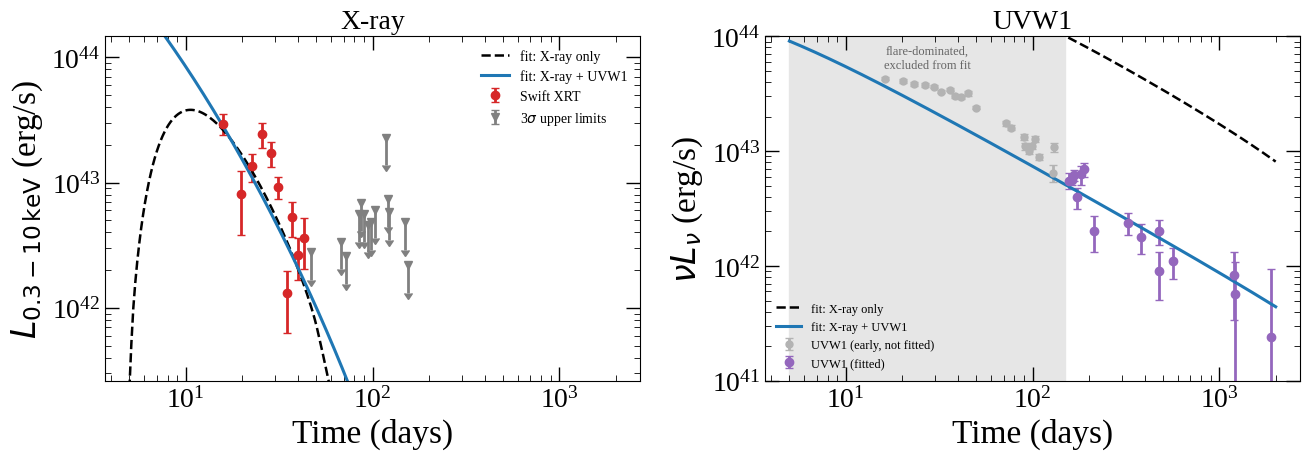

In [9]:
names = list(model_b.default_key_pars)
P_x = model_x.convert_parameters(best_x, names)
P_b = model_b.convert_parameters(best_b, names)

t_model = np.logspace(np.log10(5), np.log10(2000), 250)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))

# ---- X-ray panel ----
t_det, L_det, e_det = data_both.args_band['Swift XRT']
t_lim, L_lim, _ = data_both.args_band['Swift XRT upper limit']
ax1.errorbar(t_det, L_det, yerr=e_det, fmt='o', color='C3', ms=6, capsize=3,
             label='Swift XRT')
ax1.errorbar(t_lim, L_lim, yerr=0.4 * L_lim, uplims=True, fmt='v', color='0.5',
             ms=6, label=r'3$\sigma$ upper limits')
ax1.plot(t_model, model_x.model_X(t_model, *P_x, El=0.3, Eh=10.0),
         'k--', lw=1.8, label='fit: X-ray only')
ax1.plot(t_model, model_b.model_X(t_model, *P_b, El=0.3, Eh=10.0),
         'C0-', lw=2.2, label='fit: X-ray + UVW1')
ax1.set(xlabel='Time (days)', ylabel=r'$L_{0.3-10\,\mathrm{keV}}$ (erg/s)',
        xscale='log', yscale='log',
        ylim=(0.2 * L_det.min(), 5 * L_det.max()), title='X-ray')
ax1.legend(frameon=False, fontsize=10)

# ---- UV panel ----
ax2.errorbar(t_uv[~late], L_uv[~late], yerr=e_uv[~late], fmt='o', ms=5,
             color='0.7', capsize=3, label='UVW1 (early, not fitted)')
t_f, L_f, e_f = data_both.args_band['UVW1']
ax2.errorbar(t_f, L_f, yerr=e_f, fmt='o', ms=6, color='C4', capsize=3,
             label='UVW1 (fitted)')
ax2.plot(t_model, model_x.model_UV(t_model, *P_x, v=NU_UVW1),
         'k--', lw=1.8, label='fit: X-ray only')
ax2.plot(t_model, model_b.model_UV(t_model, *P_b, v=NU_UVW1),
         'C0-', lw=2.2, label='fit: X-ray + UVW1')
# Shade the excluded window rather than annotating a vertical line: the rotated
# label sat on top of the data points.
ax2.axvspan(t_model.min(), T_UV_MIN, color='0.9', zorder=0)
ax2.text(np.sqrt(t_model.min() * T_UV_MIN), 6.5e43, 'flare-dominated,\nexcluded from fit',
         fontsize=9, color='0.4', ha='center', va='center')
ax2.set(xlabel='Time (days)', ylabel=r'$\nu L_\nu$ (erg/s)',
        xscale='log', yscale='log', ylim=(1e41, 1e44), title='UVW1')
ax2.legend(frameon=False, fontsize=9, loc='lower left')

fig.tight_layout()
plt.show()

The UV panel shows why the X-ray-only fit went wrong: its dashed curve, which fits the
X-rays perfectly well, is nowhere near the late UV. Nothing in the X-ray data penalised
that, so nothing stopped it.

It also shows the early UV points we deliberately excluded, in grey — well above both disc
curves, because that emission is the flare component and not the disc. Tutorial 06 models
it explicitly.

## Step 7: know what you have, and what you do not

Even the better fit is a single point. The docstring of `best_fit` is blunt about this:
*"This almost never works. Maximum likelihood estimation is not very robust for large
parameter spaces."* Worth taking seriously. Two quick ways to see it:

In [10]:
# (a) Restart from a deliberately different guess and see where the optimiser lands.
alt = dict(log_mh=6.2, a_bh=0.5, m_disc=0.2, r0=200.0, tvi=40.0, t0=-10.0, incl=40.0)
alt_best = fit_b.best_fit(model_b.pack_parameters(**alt), print_best_fit=False,
                          options={'maxiter': 20000, 'maxfev': 20000})
alt_phys = model_b.convert_parameters(alt_best, names)

print("%-10s %13s %13s" % ("parameter", "from start 1", "from start 2"))
for name, a, b in zip(['log_mh', 'a_bh', 'm_disc', 'r0', 'tvi', 't0', 'incl'], P_b, alt_phys):
    print("%-10s %13.4g %13.4g" % (name, a, b))
print("\nlog L: %.2f vs %.2f" % (fit_b.log_likelihood(best_b),
                                 fit_b.log_likelihood(alt_best)))

parameter   from start 1  from start 2
log_mh             6.934         7.056
a_bh             0.02567        0.2113
m_disc           0.04723       0.01692
r0                  1554         108.5
tvi                    1          9.93
t0                0.1859        -11.88
incl               54.94         53.26

log L: -30.32 vs -32.49


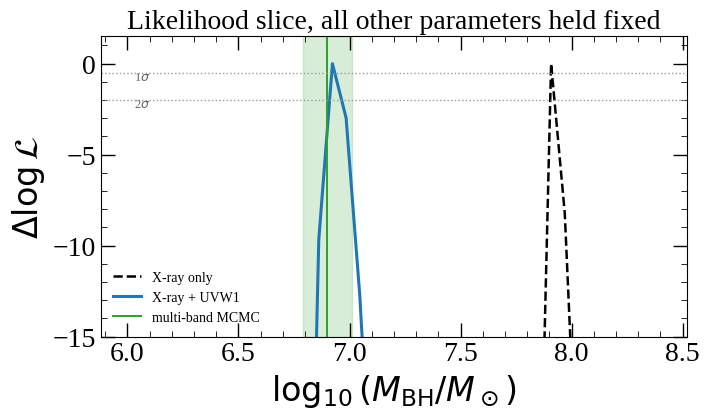

In [11]:
# (b) Slice the likelihood along the black hole mass, refitting nothing else.
masses = np.linspace(6.0, 8.4, 40)
def slice_logL(f, best):
    out = []
    for log_mh in masses:
        trial = np.array(best, dtype=float).copy()
        trial[names.index('log_mh')] = log_mh
        out.append(f.log_likelihood(trial))
    return np.array(out)

s_x, s_b = slice_logL(fit_x, best_x), slice_logL(fit_b, best_b)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(masses, s_x - s_x.max(), 'k--', lw=1.8, label='X-ray only')
ax.plot(masses, s_b - s_b.max(), 'C0-', lw=2.2, label='X-ray + UVW1')
ax.axvspan(MCMC_LOG_MH - MCMC_ERR, MCMC_LOG_MH + MCMC_ERR, color='C2', alpha=0.18)
ax.axvline(MCMC_LOG_MH, color='C2', lw=1.4, label='multi-band MCMC')
ax.axhline(-0.5, color='0.6', ls=':', lw=1)
ax.axhline(-2.0, color='0.6', ls=':', lw=1)
ax.text(6.03, -0.9, r'1$\sigma$', fontsize=9, color='0.4')
ax.text(6.03, -2.4, r'2$\sigma$', fontsize=9, color='0.4')
ax.set(xlabel=r'$\log_{10}(M_{\rm BH}/M_\odot)$',
       ylabel=r'$\Delta \log \mathcal{L}$', ylim=(-15, 1.5),
       title='Likelihood slice, all other parameters held fixed')
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

The slices make the same point geometrically. Adding the UV band narrows the mass
constraint and moves its centre onto the multi-band posterior.

Two caveats on reading them. These slices hold every other parameter **fixed**, so they
*understate* the true uncertainty: in a real fit the other parameters move to compensate,
and the marginal constraint is broader. And a slice through a 7-dimensional surface at one
point tells you nothing about the rest of it. Getting the honest width means exploring the
whole space — which is what MCMC is for, and what Tutorial 05 does.

## Optional: fitting the early-time component separately

When you *do* include the early UV and an early-time model, it often helps to fit the
early-time parameters on their own first, so the disc parameters start from a sensible place
instead of absorbing early light they cannot produce.

```python
early_pars = fit.get_early_model_pars(
    p0=None,        # initial guess; model defaults if None
    t_cut=365.25,   # only use data before this time
)
```

It optimises only `model.default_early_pars`, holding the disc fixed. It is not useful here
— our model has no early-time component — but Tutorial 06 uses it.

## Summary

- `Fit` = model + prior + statistical machinery.
- The default prior is uniform in the **sampled** variables: a Jeffreys prior on the scale
  parameters, isotropic in inclination.
- `best_fit()` optimises the posterior and returns a vector in the sampled space;
  `convert_parameters()` turns it back into physical units.
- **Which data you include dominates everything else.** One late-time UV band moved the
  black hole mass by an order of magnitude and onto the multi-band answer.
- Fit only the components your data can constrain, and exclude data your model is not
  meant to describe.
- A best-fit point is a starting position for MCMC, not a result.

## Next steps

- **Tutorial 05: MCMC Fitting with emcee** — turn this point into a posterior
- **Tutorial 07: Advanced Model Options** — accuracy and speed
- **Tutorial 06: Complete Workflow** — all bands, with the early-time model turned on

## Further reading

- **Paper Section 3**: statistical analysis (arXiv:2408.15048)